In [1]:
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
path=r"D:\项目\自我监测系统项目\苹果手表导出数据\App_Privacy_Report_2026-03-03.ndjson"
df_report=pd.read_json(path,lines=True)
print(f"表格大小：{df_report.shape}")
print(f"列名{df_report.columns}")
print(f"行名{df_report.index}")
print(f"前五行{df_report.head()}")

表格大小：(21521, 8)
列名Index(['accessCount', 'accessor', 'category', 'identifier', 'kind',
       'timeStamp', 'type', 'outOfProcess'],
      dtype='object')
行名RangeIndex(start=0, stop=21521, step=1)
前五行   accessCount                                           accessor  category  \
0            0  {'identifier': 'com.lifubing.lbs.stepOfLife', ...  location   
1            0  {'identifier': 'com.lifubing.lbs.stepOfLife', ...  location   
2            0  {'identifier': 'com.lifubing.lbs.stepOfLife', ...  location   
3            0  {'identifier': 'com.lifubing.lbs.stepOfLife', ...  location   
4            0  {'identifier': 'com.lifubing.lbs.stepOfLife', ...  location   

                             identifier           kind  \
0  41187222-A794-4897-8D47-4CB688F7ED89  intervalBegin   
1  41187222-A794-4897-8D47-4CB688F7ED89    intervalEnd   
2  7428EE62-635B-4F67-8B20-453C3C54CFDD  intervalBegin   
3  7428EE62-635B-4F67-8B20-453C3C54CFDD    intervalEnd   
4  54666312-5A96-4DEE-BEED-FF11146D6C

In [3]:
path=r"D:\项目\自我监测系统项目\苹果手表导出数据\2026-03-03.xml"

tree=ET.parse(path)
root=tree.getroot()

df=pd.DataFrame([list.attrib for list in root.findall('Record')])

print(f"{df.shape}")
print(f"{df.columns}")
print(f"{df.index}")
print(f"{df['type'].unique()}")


(48623, 9)
Index(['type', 'sourceName', 'sourceVersion', 'unit', 'creationDate',
       'startDate', 'endDate', 'value', 'device'],
      dtype='object')
RangeIndex(start=0, stop=48623, step=1)
['HKQuantityTypeIdentifierHeight' 'HKQuantityTypeIdentifierBodyMass'
 'HKQuantityTypeIdentifierHeartRate'
 'HKQuantityTypeIdentifierOxygenSaturation'
 'HKQuantityTypeIdentifierRespiratoryRate'
 'HKQuantityTypeIdentifierStepCount'
 'HKQuantityTypeIdentifierDistanceWalkingRunning'
 'HKQuantityTypeIdentifierBasalEnergyBurned'
 'HKQuantityTypeIdentifierActiveEnergyBurned'
 'HKQuantityTypeIdentifierFlightsClimbed'
 'HKQuantityTypeIdentifierAppleExerciseTime'
 'HKQuantityTypeIdentifierRestingHeartRate'
 'HKQuantityTypeIdentifierVO2Max'
 'HKQuantityTypeIdentifierWalkingHeartRateAverage'
 'HKQuantityTypeIdentifierEnvironmentalAudioExposure'
 'HKQuantityTypeIdentifierHeadphoneAudioExposure'
 'HKQuantityTypeIdentifierWalkingDoubleSupportPercentage'
 'HKQuantityTypeIdentifierAppleStandTime'
 'HKQuantityTyp

In [4]:
df['startDate']=pd.to_datetime(df['startDate']).dt.tz_localize(None)
df['endDate']=pd.to_datetime(df['endDate']).dt.tz_localize(None)

start_time=pd.to_datetime('2026-03-03 08:24:00')
end_time=pd.to_datetime('2026-03-03 22:00:00')

mask=(df['startDate']>=start_time)&(df['endDate']<=end_time)

RecordDF=df.loc[mask].copy()
RecordDF['startDate']=pd.to_datetime(RecordDF['startDate']).dt.tz_localize(None)
RecordDF['endDate']=pd.to_datetime(RecordDF['endDate']).dt.tz_localize(None)
RecordDF['value']=pd.to_numeric(RecordDF['value'],errors='coerce')


In [5]:
target_signals = {
    # --- 核心心脏与呼吸指标 ---
    'HRV': 'HKQuantityTypeIdentifierHeartRateVariabilitySDNN',
    'HR': 'HKQuantityTypeIdentifierHeartRate',
    'Respiratory': 'HKQuantityTypeIdentifierRespiratoryRate',
    'Audio': 'HKQuantityTypeIdentifierEnvironmentalAudioExposure',
    
    # --- 步态与平衡指标 (由加速度计计算) ---
    'WalkingSpeed': 'HKQuantityTypeIdentifierWalkingSpeed',
    'WalkingStepLength': 'HKQuantityTypeIdentifierWalkingStepLength',
    'WalkingDoubleSupportPercentage': 'HKQuantityTypeIdentifierWalkingDoubleSupportPercentage',
    'WalkingAsymmetry': 'HKQuantityTypeIdentifierWalkingAsymmetryPercentage', # 建议加上这个，看左右平衡
    
    # --- 活动与能量消耗 ---
    'StepCount': 'HKQuantityTypeIdentifierStepCount',
    'ActiveEnergyBurned': 'HKQuantityTypeIdentifierActiveEnergyBurned',
    'PhysicalEffort': 'HKQuantityTypeIdentifierPhysicalEffort',
    
    # --- 综合步行指标 ---
    'WalkingHeartRateAverage': 'HKQuantityTypeIdentifierWalkingHeartRateAverage'
}

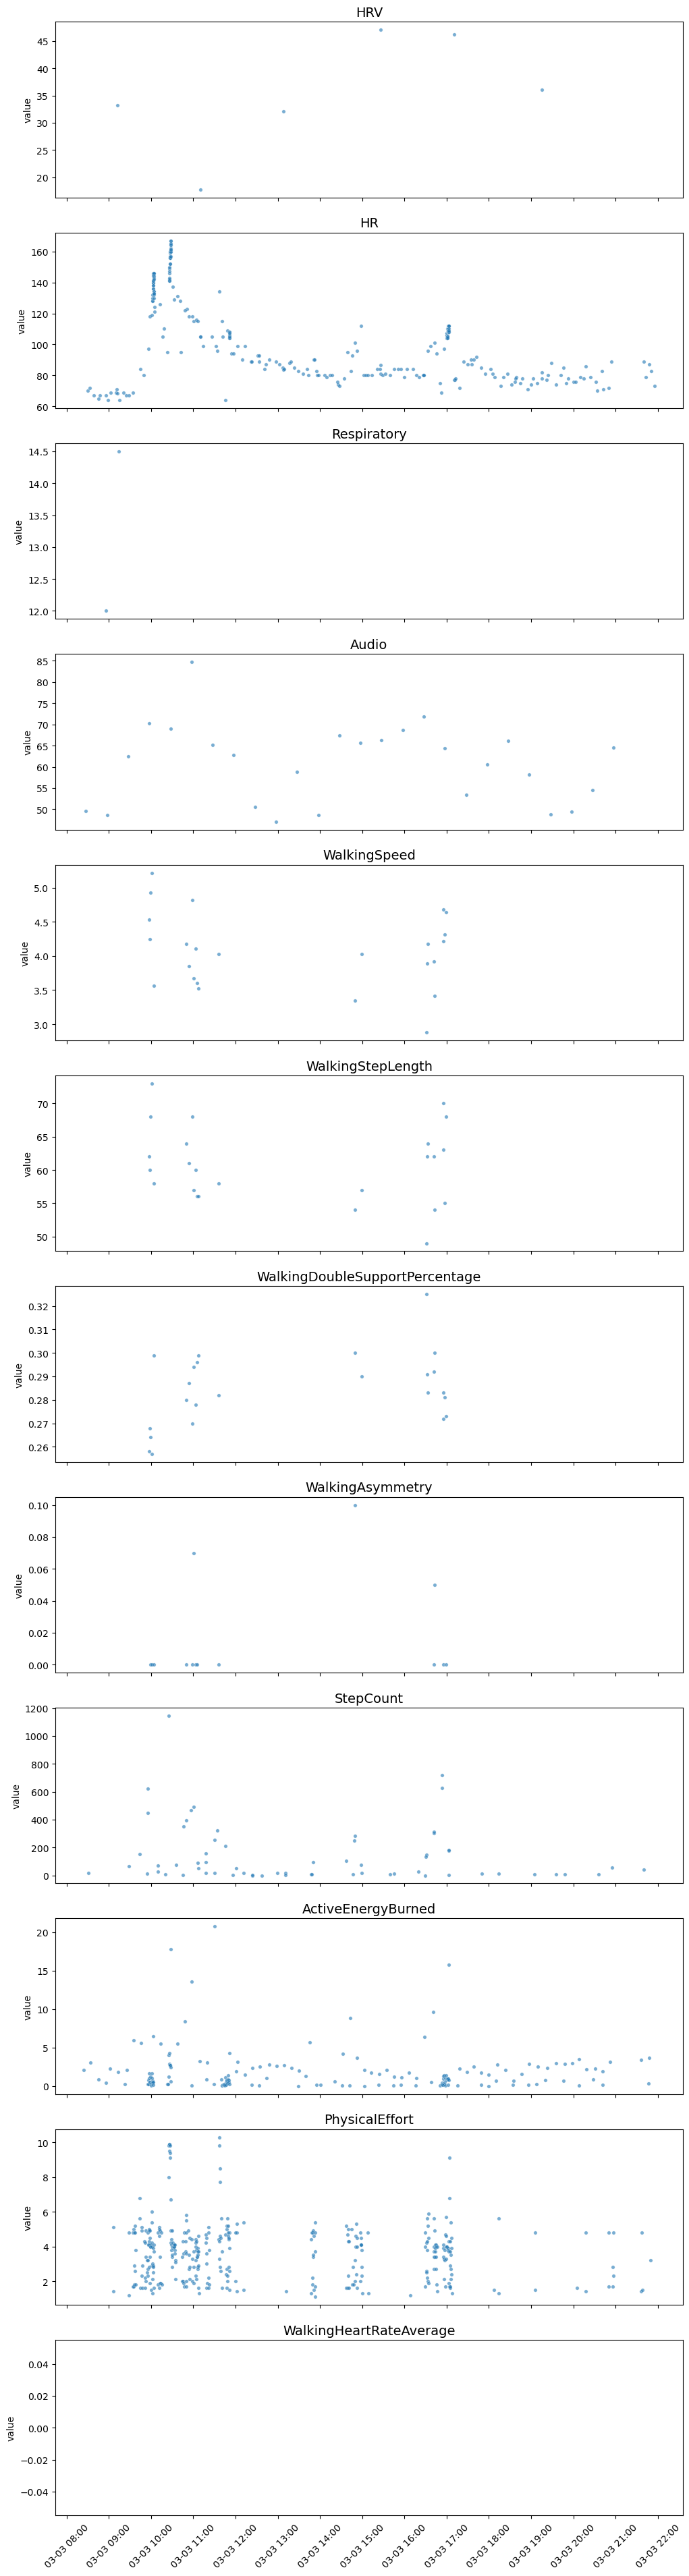

In [6]:
fig,axes=plt.subplots(len(target_signals),1,figsize=(12,4*len(target_signals)),sharex=True)
for i,(name,identifier) in enumerate(target_signals.items()):
    data=RecordDF[RecordDF['type']==identifier]
    sns.scatterplot(data=data,x='startDate',y='value',ax=axes[i],s=15,alpha=0.6)
    axes[i].xaxis.set_major_locator(mdates.HourLocator(interval=1))
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    axes[i].tick_params(axis='x',rotation=45)
    axes[i].set_ylabel('value')
    axes[i].set_title(name,fontsize=14)
plt.show()